In [1]:
# Install geospatial and ML libraries needed for the assignment
!pip install geopandas rasterio shapely geemap seaborn scikit-learn torch torchvision

In [2]:
# STEP 1: VERIFY DATASET

# We install required geospatial libraries
!pip install geopandas rasterio shapely geemap --quiet

# Import required libraries
import os
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, box

# Check dataset folder

# This is the dataset base path
dataset_path = "/kaggle/input/datasets/dheerajmg/ai-sustainability-dataset"

# List files in dataset
print("Files in dataset folder:")
print(os.listdir(dataset_path))

# Check RGB images folder

rgb_path = dataset_path + "/rgb"

# Count number of RGB satellite images
rgb_images = os.listdir(rgb_path)

print("\nTotal RGB satellite images:", len(rgb_images))

# Print first few filenames to understand coordinate format
print("\nSample image filenames:")
print(rgb_images[:10])

Files in dataset folder:
['delhi_airshed.geojson', 'rgb', 'delhi_ncr_region.geojson', 'worldcover_bbox_delhi_ncr_2021.tif']

Total RGB satellite images: 9216

Sample image filenames:
['28.2266_77.5234.png', '28.4266_77.2822.png', '28.7591_77.2058.png', '28.5355_77.3910.png', '28.2943_77.0234.png', '28.6942_77.1821.png', '28.9266_77.4321.png', '28.2442_77.1821.png', '28.9178_77.0909.png', '28.7591_76.8646.png']


Delhi NCR Data Info:
                                            geometry
0  POLYGON ((76.85108 28.22115, 76.85219 28.22098...
1  POLYGON ((77.15903 29.29436, 77.15999 29.29427...
2  MULTIPOLYGON (((77.07565 27.27704, 77.07819 27...
3  POLYGON ((77.97073 28.71104, 77.97089 28.71096...
4  POLYGON ((77.2143 28.78524, 77.21521 28.78514,...


<Figure size 800x800 with 0 Axes>

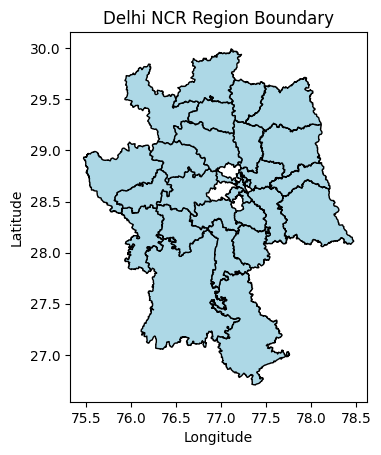

In [3]:
# STEP 2: LOAD DELHI NCR SHAPEFILE

# We load the Delhi NCR region GeoJSON file using geopandas
delhi_ncr = gpd.read_file("/kaggle/input/datasets/dheerajmg/ai-sustainability-dataset/delhi_ncr_region.geojson")

# Print basic information about the shapefile
print("Delhi NCR Data Info:")
print(delhi_ncr.head())

# Plot Delhi NCR region

# We plot the region using matplotlib
plt.figure(figsize=(8,8))

delhi_ncr.plot(edgecolor="black", facecolor="lightblue")

plt.title("Delhi NCR Region Boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Current CRS: EPSG:32644
Bounding box coordinates:
xmin: -39135.081494243466 ymin: 2958988.235697051
xmax: 252193.69892669076 ymax: 3324410.040147016
Total grid cells created: 35


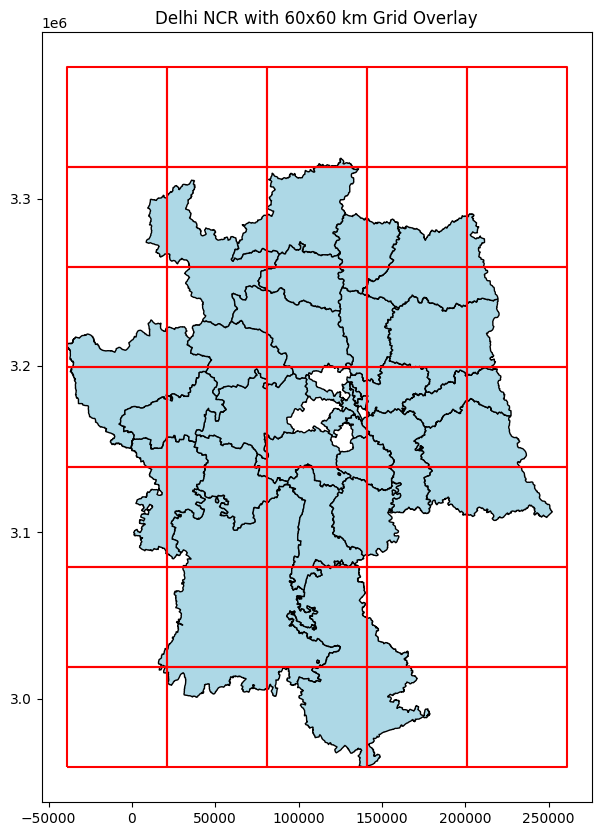

In [4]:
# STEP 3: CONVERT CRS AND CREATE 60x60 KM GRID

# Convert the Delhi NCR shapefile to EPSG:32644
# This coordinate system uses meters, which allows us to create grids in kilometers
delhi_ncr_proj = delhi_ncr.to_crs("EPSG:32644")

# Print CRS to confirm conversion
print("Current CRS:", delhi_ncr_proj.crs)

# Calculate the bounding box of the region

# total_bounds returns (xmin, ymin, xmax, ymax)
xmin, ymin, xmax, ymax = delhi_ncr_proj.total_bounds

print("Bounding box coordinates:")
print("xmin:", xmin, "ymin:", ymin)
print("xmax:", xmax, "ymax:", ymax)

# Create 60 km x 60 km grid

grid_size = 60000   # 60 km = 60000 meters

grid_cells = []

# Generate grid squares across the bounding box
for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        
        # Create a square grid cell
        cell = box(x, y, x + grid_size, y + grid_size)
        
        grid_cells.append(cell)

# Convert grid cells to GeoDataFrame
grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=delhi_ncr_proj.crs)

print("Total grid cells created:", len(grid))

# Plot Delhi NCR with grid overlay

fig, ax = plt.subplots(figsize=(10,10))

# Plot Delhi NCR boundary
delhi_ncr_proj.plot(ax=ax, facecolor="lightblue", edgecolor="black")

# Plot grid boundaries
grid.boundary.plot(ax=ax, color="red")

plt.title("Delhi NCR with 60x60 km Grid Overlay")
plt.show()

In [5]:
# STEP 4: FILTER IMAGES INSIDE DELHI NCR

# Convert the shapefile back to EPSG:4326 (latitude/longitude)
# because our image coordinates are in lat/lon
delhi_ncr_latlon = delhi_ncr.to_crs("EPSG:4326")

# Total images before filtering
total_images = len(rgb_images)

print("Total images before filtering:", total_images)

# List to store images inside Delhi NCR
inside_images = []

# Loop through each image filename
for img in rgb_images:
    
    # Remove .png extension and split coordinates
    lat, lon = img.replace(".png","").split("_")
    
    lat = float(lat)
    lon = float(lon)
    
    # Create a point geometry
    point = Point(lon, lat)
    
    # Check if point lies inside Delhi NCR region
    if delhi_ncr_latlon.contains(point).any():
        inside_images.append(img)

# Total images after filtering
print("Images inside Delhi NCR:", len(inside_images))

Total images before filtering: 9216
Images inside Delhi NCR: 8015


In [6]:
# STEP 5: LOAD LAND COVER RASTER

# Path to the ESA WorldCover raster file
landcover_path = "/kaggle/input/datasets/dheerajmg/ai-sustainability-dataset/worldcover_bbox_delhi_ncr_2021.tif"

# Open the raster using rasterio
landcover = rasterio.open(landcover_path)

# Print raster metadata
print("Raster Metadata:")
print(landcover.meta)

# Print raster CRS
print("\nRaster CRS:", landcover.crs)

# Print raster resolution
print("\nRaster Resolution:", landcover.res)

# Print raster width and height
print("\nRaster Size:", landcover.width, "x", landcover.height)

Raster Metadata:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 9602, 'height': 9600, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.333333333333333e-05, 0.0, 76.84991666666667,
       0.0, -8.333333333333333e-05, 29.0)}

Raster CRS: EPSG:4326

Raster Resolution: (8.333333333333333e-05, 8.333333333333333e-05)

Raster Size: 9602 x 9600


Sample image: 28.2266_77.5234.png
Latitude: 28.2266
Longitude: 77.5234
Raster pixel location:
Row: 9280 Column: 8081
Patch shape: (128, 128)


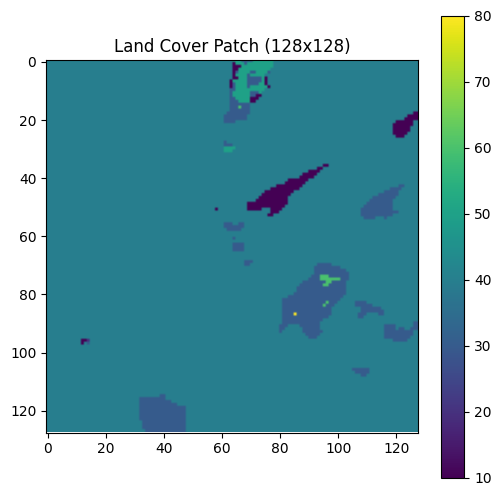

In [7]:
# STEP 6: EXTRACT LAND COVER PATCH

# We will test the process on ONE image first

# Select the first filtered image
sample_image = inside_images[0]

print("Sample image:", sample_image)

# Extract coordinates from filename

lat, lon = sample_image.replace(".png","").split("_")

lat = float(lat)
lon = float(lon)

print("Latitude:", lat)
print("Longitude:", lon)

# Convert coordinates → raster pixel index

row, col = landcover.index(lon, lat)

print("Raster pixel location:")
print("Row:", row, "Column:", col)

# ==============================
# Extract 128×128 patch centered at this location
# ==============================

patch = landcover.read(1)[row-64:row+64, col-64:col+64]

print("Patch shape:", patch.shape)

# ==============================
# Show the patch
# ==============================

plt.figure(figsize=(6,6))
plt.imshow(patch)
plt.title("Land Cover Patch (128x128)")
plt.colorbar()
plt.show()

In [8]:
# STEP 7: FIND DOMINANT LAND COVER CLASS

# We calculate the most frequent value (mode) in the patch
# This value represents the dominant land cover class

from scipy.stats import mode

dominant_class = mode(patch.flatten(), keepdims=False).mode

print("Dominant ESA Land Cover Class:", dominant_class)

# Map ESA classes → simplified land use categories

# ESA WorldCover class mapping
class_mapping = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow / Ice",
    80: "Water",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss / lichen"
}

# Get readable class label
landuse_label = class_mapping.get(int(dominant_class), "Unknown")

print("Dominant Land Use Category:", landuse_label)

Dominant ESA Land Cover Class: 40
Dominant Land Use Category: Cropland


In [9]:
# STEP 8: CREATE LABELED DATASET

dataset = []

for img in inside_images:
    
    # Extract coordinates
    lat, lon = img.replace(".png","").split("_")
    
    lat = float(lat)
    lon = float(lon)
    
    try:
        # Convert coordinates → raster pixel
        row, col = landcover.index(lon, lat)
        
        # Extract 128×128 patch
        patch = landcover.read(1)[row-64:row+64, col-64:col+64]
        
        # Skip invalid patches near borders
        if patch.shape != (128,128):
            continue
        
        # Find dominant class
        dominant_class = mode(patch.flatten(), keepdims=False).mode
        
        # Map class
        landuse_label = class_mapping.get(int(dominant_class), "Unknown")
        
        # Save result
        dataset.append([img, landuse_label])
        
    except:
        continue


print("Total labeled samples:", len(dataset))

Total labeled samples: 8015


In [10]:
# STEP 9: CONVERT DATASET TO DATAFRAME


import pandas as pd

# Convert dataset list → DataFrame
df = pd.DataFrame(dataset, columns=["image", "label"])

# Show first few rows
print("Sample dataset:")
print(df.head())

# Show dataset size
print("\nTotal samples:", len(df))

Sample dataset:
                 image       label
0  28.2266_77.5234.png    Cropland
1  28.4266_77.2822.png    Cropland
2  28.7591_77.2058.png    Cropland
3  28.5355_77.3910.png    Built-up
4  28.2943_77.0234.png  Tree cover

Total samples: 8015


In [11]:
# STEP 10: TRAIN TEST SPLIT (60/40)

from sklearn.model_selection import train_test_split

# Split dataset into train (60%) and test (40%)
train_df, test_df = train_test_split(
    df,
    test_size=0.4,
    random_state=42,
    stratify=df["label"]   # keeps class balance
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 4809
Testing samples: 3206


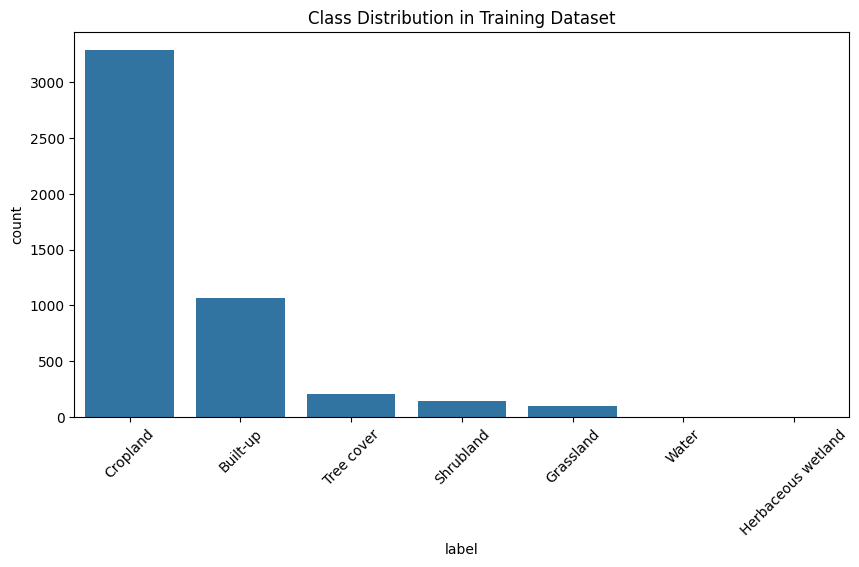

In [12]:
# STEP 11: VISUALIZE CLASS DISTRIBUTION

import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(data=train_df, x="label", order=train_df["label"].value_counts().index)

plt.title("Class Distribution in Training Dataset")
plt.xticks(rotation=45)

plt.show()

In [13]:
# STEP 12: PREPARE IMAGE DATASET FOR CNN

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Path to RGB images
rgb_path = "/kaggle/input/datasets/dheerajmg/ai-sustainability-dataset/rgb"

# Convert labels → numeric values
label_to_index = {label: idx for idx, label in enumerate(df["label"].unique())}
index_to_label = {v:k for k,v in label_to_index.items()}

print("Label mapping:")
print(label_to_index)

# Convert labels in dataframe
train_df["label_id"] = train_df["label"].map(label_to_index)
test_df["label_id"] = test_df["label"].map(label_to_index)

# Image transformations
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

# Custom Dataset class
class SatelliteDataset(Dataset):
    
    def __init__(self, dataframe):
        self.df = dataframe
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        img_name = self.df.iloc[idx]["image"]
        label = self.df.iloc[idx]["label_id"]
        
        img_path = rgb_path + "/" + img_name
        
        image = Image.open(img_path).convert("RGB")
        image = transform(image)
        
        return image, label


# Create datasets
train_dataset = SatelliteDataset(train_df)
test_dataset = SatelliteDataset(test_df)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Label mapping:
{'Cropland': 0, 'Built-up': 1, 'Tree cover': 2, 'Shrubland': 3, 'Grassland': 4, 'Water': 5, 'Herbaceous wetland': 6}
Training batches: 151
Testing batches: 101


In [14]:
# STEP 13: TRAIN RESNET18 MODEL

import torch
import torch.nn as nn
import torchvision.models as models

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Replace final layer for our 7 classes
num_classes = len(label_to_index)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 15

for epoch in range(epochs):
    
    model.train()
    
    running_loss = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Epoch 1/15, Loss: 0.4496
Epoch 2/15, Loss: 0.3195
Epoch 3/15, Loss: 0.2853
Epoch 4/15, Loss: 0.2335
Epoch 5/15, Loss: 0.2174
Epoch 6/15, Loss: 0.1504
Epoch 7/15, Loss: 0.1760
Epoch 8/15, Loss: 0.0883
Epoch 9/15, Loss: 0.0938
Epoch 10/15, Loss: 0.0539
Epoch 11/15, Loss: 0.0617
Epoch 12/15, Loss: 0.0646
Epoch 13/15, Loss: 0.0698
Epoch 14/15, Loss: 0.0657
Epoch 15/15, Loss: 0.0367


In [15]:
# STEP 14: MODEL EVALUATION

from sklearn.metrics import accuracy_score, f1_score
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Calculate F1 score
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", accuracy)
print("F1 Score:", f1)

Test Accuracy: 0.8933250155957579
F1 Score: 0.8893103874453879


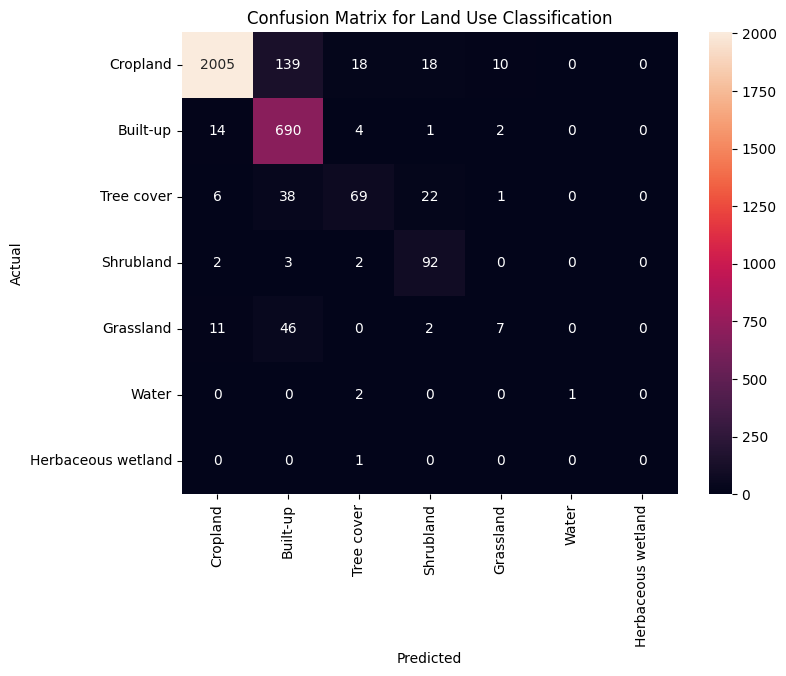

In [16]:
# STEP 15: CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=index_to_label.values(),
    yticklabels=index_to_label.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Land Use Classification")

plt.show()

In [17]:
# I have done the complete pipeline involving spatial gridding, land cover classification.

The model performs well for dominant classes like Cropland and Built-up due to their strong spatial patterns in satellite imagery. Some confusion occurs between Tree cover and Shrubland, which is expected because these classes share similar vegetation textures in RGB imagery.